In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8x.pt conf=0.25

/content/ByteTrack
100% 131M/131M [00:00<00:00, 343MB/s]
WARNING ⚠️ 'source' argument is missing. Using default 'source=/usr/local/lib/python3.10/dist-packages/ultralytics/assets'.
Ultralytics YOLOv8.2.29 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8x summary (fused): 268 layers, 68200608 parameters, 0 gradients, 257.8 GFLOPs

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
image 1/2 /usr/local/lib/python3.10/dist-packages/ultralytics/assets/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 97.0ms
image 2/2 /usr/local/lib/python3.10/dist-packages/ultralytics/assets/zidane.jpg: 384x640 2 persons, 1 tie, 76.2ms
Speed: 7.4ms preprocess, 86.6ms inference, 355.4ms pos

In [ ]:
 # Pip install method (recommended)

!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.29 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 30.4/78.2 GB disk)


In [ ]:
SOURCE_VIDEO_PATH = "/content/traffic video.mp4"


In [ ]:
%cd {HOME}
!git clone https://github.com/ifzhang/ByteTrack.git
%cd {HOME}/ByteTrack

!sed -i 's/onnx==1.8.1/onnx==1.9.0/g' requirements.txt

!pip3 install -q -r requirements.txt
!python3 setup.py -q develop
!pip install -q cython_bbox
!pip install -q onemetric

!pip install -q loguru lap thop

from IPython import display
display.clear_output()


import sys
sys.path.append(f"{HOME}/ByteTrack")


import yolox
print("yolox.__version__:", yolox.__version__)

yolox.__version__: 0.1.0


In [ ]:
!pip install supervision==0.1.0


from IPython import display
display.clear_output()


import supervision
print("supervision.__version__:", supervision.__version__)

supervision.__version__: 0.1.0


In [ ]:
from supervision.draw.color import ColorPalette
from supervision.geometry.dataclasses import Point
from supervision.video.dataclasses import VideoInfo
from supervision.video.source import get_video_frames_generator
from supervision.video.sink import VideoSink
from supervision.notebook.utils import show_frame_in_notebook
from supervision.tools.detections import Detections, BoxAnnotator
from supervision.tools.line_counter import LineCounter, LineCounterAnnotator

In [ ]:
# settings
MODEL = "yolov8x.pt"
from ultralytics import YOLO

model = YOLO(MODEL)
model.fuse()

100%|██████████| 131M/131M [00:00<00:00, 400MB/s]


YOLOv8x summary (fused): 268 layers, 68200608 parameters, 0 gradients, 257.8 GFLOPs


In [ ]:
# dict maping class_id to class_name
CLASS_NAMES_DICT = model.model.names
# class_ids of interest - car, motorcycle, bus and truck
CLASS_ID = [2, 3, 5, 7]
CLASS_NAMES_DICT

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou


0: 384x640 25 cars, 2 buss, 5 trucks, 3 traffic lights, 121.8ms
Speed: 3.2ms preprocess, 121.8ms inference, 505.7ms postprocess per image at shape (1, 3, 384, 640)


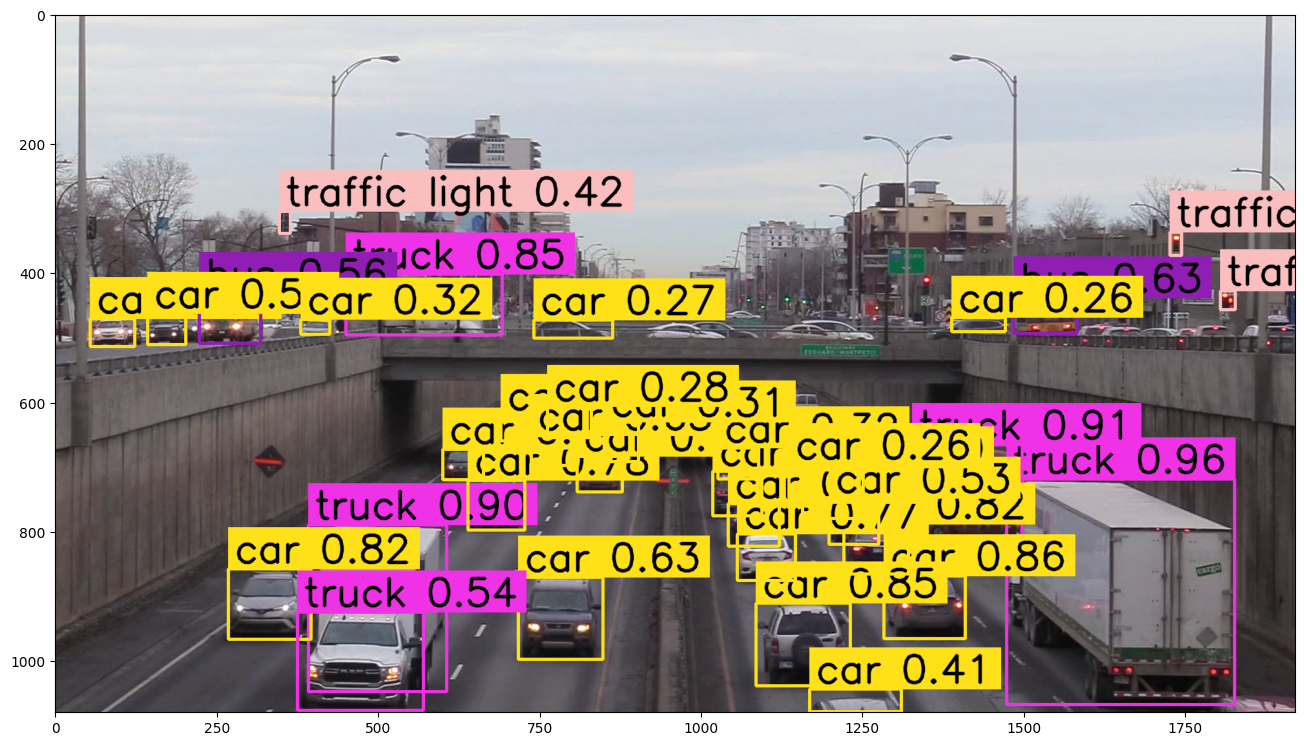

In [ ]:
# create frame generator
generator = get_video_frames_generator(SOURCE_VIDEO_PATH)
# create instance of BoxAnnotator
box_annotator = BoxAnnotator(color=ColorPalette(), thickness=4, text_thickness=4, text_scale=2)
# acquire first video frame
iterator = iter(generator)
frame = next(iterator)
# model prediction on single frame and conversion to supervision Detections
results = model(frame)
detections = Detections(
    xyxy=results[0].boxes.xyxy.cpu().numpy(),
    confidence=results[0].boxes.conf.cpu().numpy(),
    class_id=results[0].boxes.cls.cpu().numpy().astype(int)
)
# format custom labels
labels = [
    f"{CLASS_NAMES_DICT[class_id]} {confidence:0.2f}"
    for _, confidence, class_id, tracker_id
    in detections
]
# annotate and display frame
frame = box_annotator.annotate(frame=frame, detections=detections, labels=labels)

%matplotlib inline
show_frame_in_notebook(frame, (16, 16))

In [ ]:
# Navigate to a specific directory
%cd /content

# Create a new folder named "my_folder" in the specified directory
!mkdir my_folder


/content


In [ ]:
import cv2
import numpy as np
from IPython.display import HTML
from base64 import b64encode
from ultralytics import YOLO
import supervision

# Define function to encode video to HTML5
def show_video_in_notebook(video_path):
    video = open(video_path, "rb").read()
    video_encoded = b64encode(video).decode("ascii")
    video_tag = f'<video controls alt="test" src="data:video/mp4;base64,{video_encoded}">'
    return HTML(video_tag)

# Define function for object detection and annotation
def detect_and_annotate_video(source_video_path, output_video_path, model_path):
    model = YOLO(model_path)
    model.fuse()

    # Define dictionary mapping class_id to class_name
    CLASS_NAMES_DICT = model.model.names

    # Create frame generator
    generator = supervision.video.source.get_video_frames_generator(source_video_path)

    # Create instance of BoxAnnotator
    box_annotator = supervision.tools.detections.BoxAnnotator(color=supervision.draw.color.ColorPalette(), thickness=4, text_thickness=4, text_scale=2)

    # Define a list to store annotated frames
    annotated_frames = []

    # Iterate over each frame in the video
    for frame in generator:
        # Model prediction on single frame and conversion to supervision Detections
        results = model(frame)
        detections = supervision.tools.detections.Detections(
            xyxy=results[0].boxes.xyxy.cpu().numpy(),
            confidence=results[0].boxes.conf.cpu().numpy(),
            class_id=results[0].boxes.cls.cpu().numpy().astype(int)
        )

        # Format custom labels
        labels = [
            f"{CLASS_NAMES_DICT[class_id]} {confidence:0.2f}"
            for _, confidence, class_id, tracker_id
            in detections
        ]

        # Annotate frame
        annotated_frame = box_annotator.annotate(frame=frame, detections=detections, labels=labels)

        # Convert OpenCV BGR format to RGB format
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

        # Append annotated frame to list
        annotated_frames.append(annotated_frame_rgb)

    # Define video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_video_path, fourcc, 30, (annotated_frames[0].shape[1], annotated_frames[0].shape[0]))

    # Write annotated frames to video
    for frame in annotated_frames:
        video_writer.write(frame)

    # Release video writer
    video_writer.release()

    # Display annotated video in notebook
    return show_video_in_notebook(output_video_path)

# Define paths
SOURCE_VIDEO_PATH = "/content/traffic video.mp4"
OUTPUT_VIDEO_PATH = "/content/my_folder/annotated_video.mp4"
MODEL_PATH = "yolov8x.pt"

# Call the function to detect and annotate video
detect_and_annotate_video(SOURCE_VIDEO_PATH, OUTPUT_VIDEO_PATH, MODEL_PATH)


YOLOv8x summary (fused): 268 layers, 68200608 parameters, 0 gradients, 257.8 GFLOPs

0: 384x640 25 cars, 2 buss, 5 trucks, 3 traffic lights, 56.5ms
Speed: 2.1ms preprocess, 56.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 24 cars, 2 buss, 7 trucks, 3 traffic lights, 55.8ms
Speed: 2.7ms preprocess, 55.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 cars, 2 buss, 6 trucks, 4 traffic lights, 37.5ms
Speed: 2.8ms preprocess, 37.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 27 cars, 2 buss, 5 trucks, 4 traffic lights, 34.2ms
Speed: 3.3ms preprocess, 34.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 cars, 2 buss, 5 trucks, 5 traffic lights, 33.5ms
Speed: 2.9ms preprocess, 33.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 25 cars, 2 buss, 6 trucks, 5 traffic lights, 32.8ms
Speed: 3.2ms preprocess, 32.8ms inference, 1.3m